
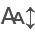

In [1]:
from itables import init_notebook_mode, show
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

import importlib
import aacbr 

init_notebook_mode(all_interactive=True)

In [2]:
def reload_imports():
    importlib.reload(aacbr)

## Data Set

In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
connectionist_bench_sonar_mines_vs_rocks = fetch_ucirepo(id=151) 
  
# data (as pandas dataframes) 
X = connectionist_bench_sonar_mines_vs_rocks.data.features 
y = connectionist_bench_sonar_mines_vs_rocks.data.targets 

show(X)
print(y.nunique())



class    2
dtype: int64


In [4]:
encoder = LabelEncoder()
encoder.fit(y)
y = encoder.transform(y)


/home/adam/.pyenv/versions/3.10.13/envs/gradual-aacbr/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:97: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/adam/.pyenv/versions/3.10.13/envs/gradual-aacbr/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:132: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


In [5]:
print(encoder.classes_)
print(y)
print(type(y))

['M' 'R']
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
<class 'numpy.ndarray'>


In [6]:
X = X.values
print(X)

[[0.02   0.0371 0.0428 ... 0.0084 0.009  0.0032]
 [0.0453 0.0523 0.0843 ... 0.0049 0.0052 0.0044]
 [0.0262 0.0582 0.1099 ... 0.0164 0.0095 0.0078]
 ...
 [0.0522 0.0437 0.018  ... 0.0138 0.0077 0.0031]
 [0.0303 0.0353 0.049  ... 0.0079 0.0036 0.0048]
 [0.026  0.0363 0.0136 ... 0.0036 0.0061 0.0115]]


## Train Model

### Split into Training and Test Sets

In [7]:
SEED = 42

In [8]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=SEED)
print(f"Test Size:  {len(X_test)}")
print(f"Train Size:  {len(X_train)}")
print(f"Validation Size:  {len(X_val)}")



Test Size:  42
Train Size:  132
Validation Size:  34


In [9]:
print(X_train)

[[0.026  0.0363 0.0136 ... 0.0036 0.0061 0.0115]
 [0.0368 0.0403 0.0317 ... 0.0067 0.0078 0.0068]
 [0.009  0.0062 0.0253 ... 0.0053 0.0189 0.0102]
 ...
 [0.0423 0.0321 0.0709 ... 0.0021 0.0043 0.0017]
 [0.01   0.0194 0.0155 ... 0.0019 0.0053 0.0019]
 [0.0293 0.0378 0.0257 ... 0.0055 0.005  0.0087]]


### Build AF

In [10]:
# TODO: Consider more sophisticated orders

# Compare against the average for each column
means = X_train.mean(axis=0)
std = X_train.std(axis=0)

STD_PARAM = 2

def binarise_by_normal(case):
    return np.where(np.abs(case - means) <= STD_PARAM*std, 0, 1)


def strictsuperset(a, b):

    if b.ndim == 1:
        b = np.expand_dims(b, axis = 0)

    anb = a & b
    return np.logical_and(np.all(anb == b, axis = -1), np.logical_not(np.all(anb == a, axis = -1)))


In [171]:
def to_stds(case):

    case = case - means

    conditions = [case >=  3 * std, case >=  2 * std, case >=  1.5 * std, 
                  case > -1.5 * std,
                  case <= -3 * std, case <= -2 * std, case <= -1.5 * std ]

    # choices = [3, 2, 1, 0, 3, 2, 1]
    # choices = [3, 2, 0, 0, 3, 2, 0]

    choices = [3, 2, 1, 0, -3, -2, -1]
    # choices = [3, 2, 0, 0, -3, -2, 0]
    return np.select(conditions, choices)
    


def strictstdcomp(a, b):
    if b.ndim == 1:
        b = np.expand_dims(b, axis = 0)
    same_sign_or_zero = np.all(np.logical_or(np.sign(a) == np.sign(b), np.logical_or(a == 0, b == 0)), axis = -1)
    further_from_zero = np.all(np.abs(a) >= np.abs(b), axis = -1)
    noteq = np.any(a != b, axis = -1)

    return np.logical_and(same_sign_or_zero, np.logical_and(further_from_zero, noteq))


In [172]:
# COMPARISON_FUNC = strictsuperset
# PREPROCESS_FUNC = binarise_by_normal 
COMPARISON_FUNC = strictstdcomp
PREPROCESS_FUNC = to_stds 

In [173]:
DEFAULT_OUTCOME = 1
DEFAULT_CASE = means.copy()
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

In [179]:
reload_imports()
def run_model(X_train, y_train, X_test, y_test, show_graph=False):
    X_train = PREPROCESS_FUNC(X_train)
    X_test = PREPROCESS_FUNC(X_test)
    default_case = PREPROCESS_FUNC(DEFAULT_CASE)
    
    model = aacbr.AACBR(X_train, y_train, COMPARISON_FUNC, default_case, DEFAULT_OUTCOME)


    if show_graph:
        show(model.A)
        model.show_graph_with_labels()
        model.show_matrix()
    
    predicted = model(X_test)
    
    return([
        accuracy_score(y_test, predicted),
        precision_score(y_test, predicted),
        recall_score(y_test, predicted),
        f1_score(y_test, predicted)
    ])

### Cross-Validation

In [188]:
reload_imports()
metrics = []
for fold, (train_index,  val_index) in enumerate(kf.split(X_train)):
    training_instances = X_train[train_index]
    training_labels = y_train[train_index]
    validation_instances = X_train[val_index]
    validation_labels = y_train[val_index]


    metrics.append(
        run_model(training_instances, training_labels, validation_instances, validation_labels)
    )

print("Accuracy, Precision, Recall, F1")
print(np.mean(metrics, axis=0))
# for metric in metrics:
#     print(metric)


Accuracy, Precision, Recall, F1
[0.48518519 0.40039683 0.24835165 0.30464897]


[0, 23, 25, 28, 29, 89, 100, 101, 111, 131, 132, 1, 16, 76, 2, 30, 38, 46, 54, 60, 66, 68, 69, 75, 81, 85, 94, 107, 127, 128, 4, 5, 44, 6, 7, 8, 121, 9, 10, 11, 12, 65, 13, 14, 15, 17, 18, 82, 19, 88, 20, 70, 22, 117, 24, 26, 27, 31, 33, 63, 34, 35, 37, 39, 123, 41, 42, 43, 45, 47, 48, 104, 49, 50, 52, 53, 55, 56, 57, 58, 59, 61, 62, 67, 64, 72, 74, 78, 79, 80, 83, 84, 86, 90, 91, 93, 97, 98, 99, 102, 103, 105, 106, 108, 109, 110, 112, 113, 114, 115, 116, 71, 130, 118, 119, 120, 122, 125, 126, 129]


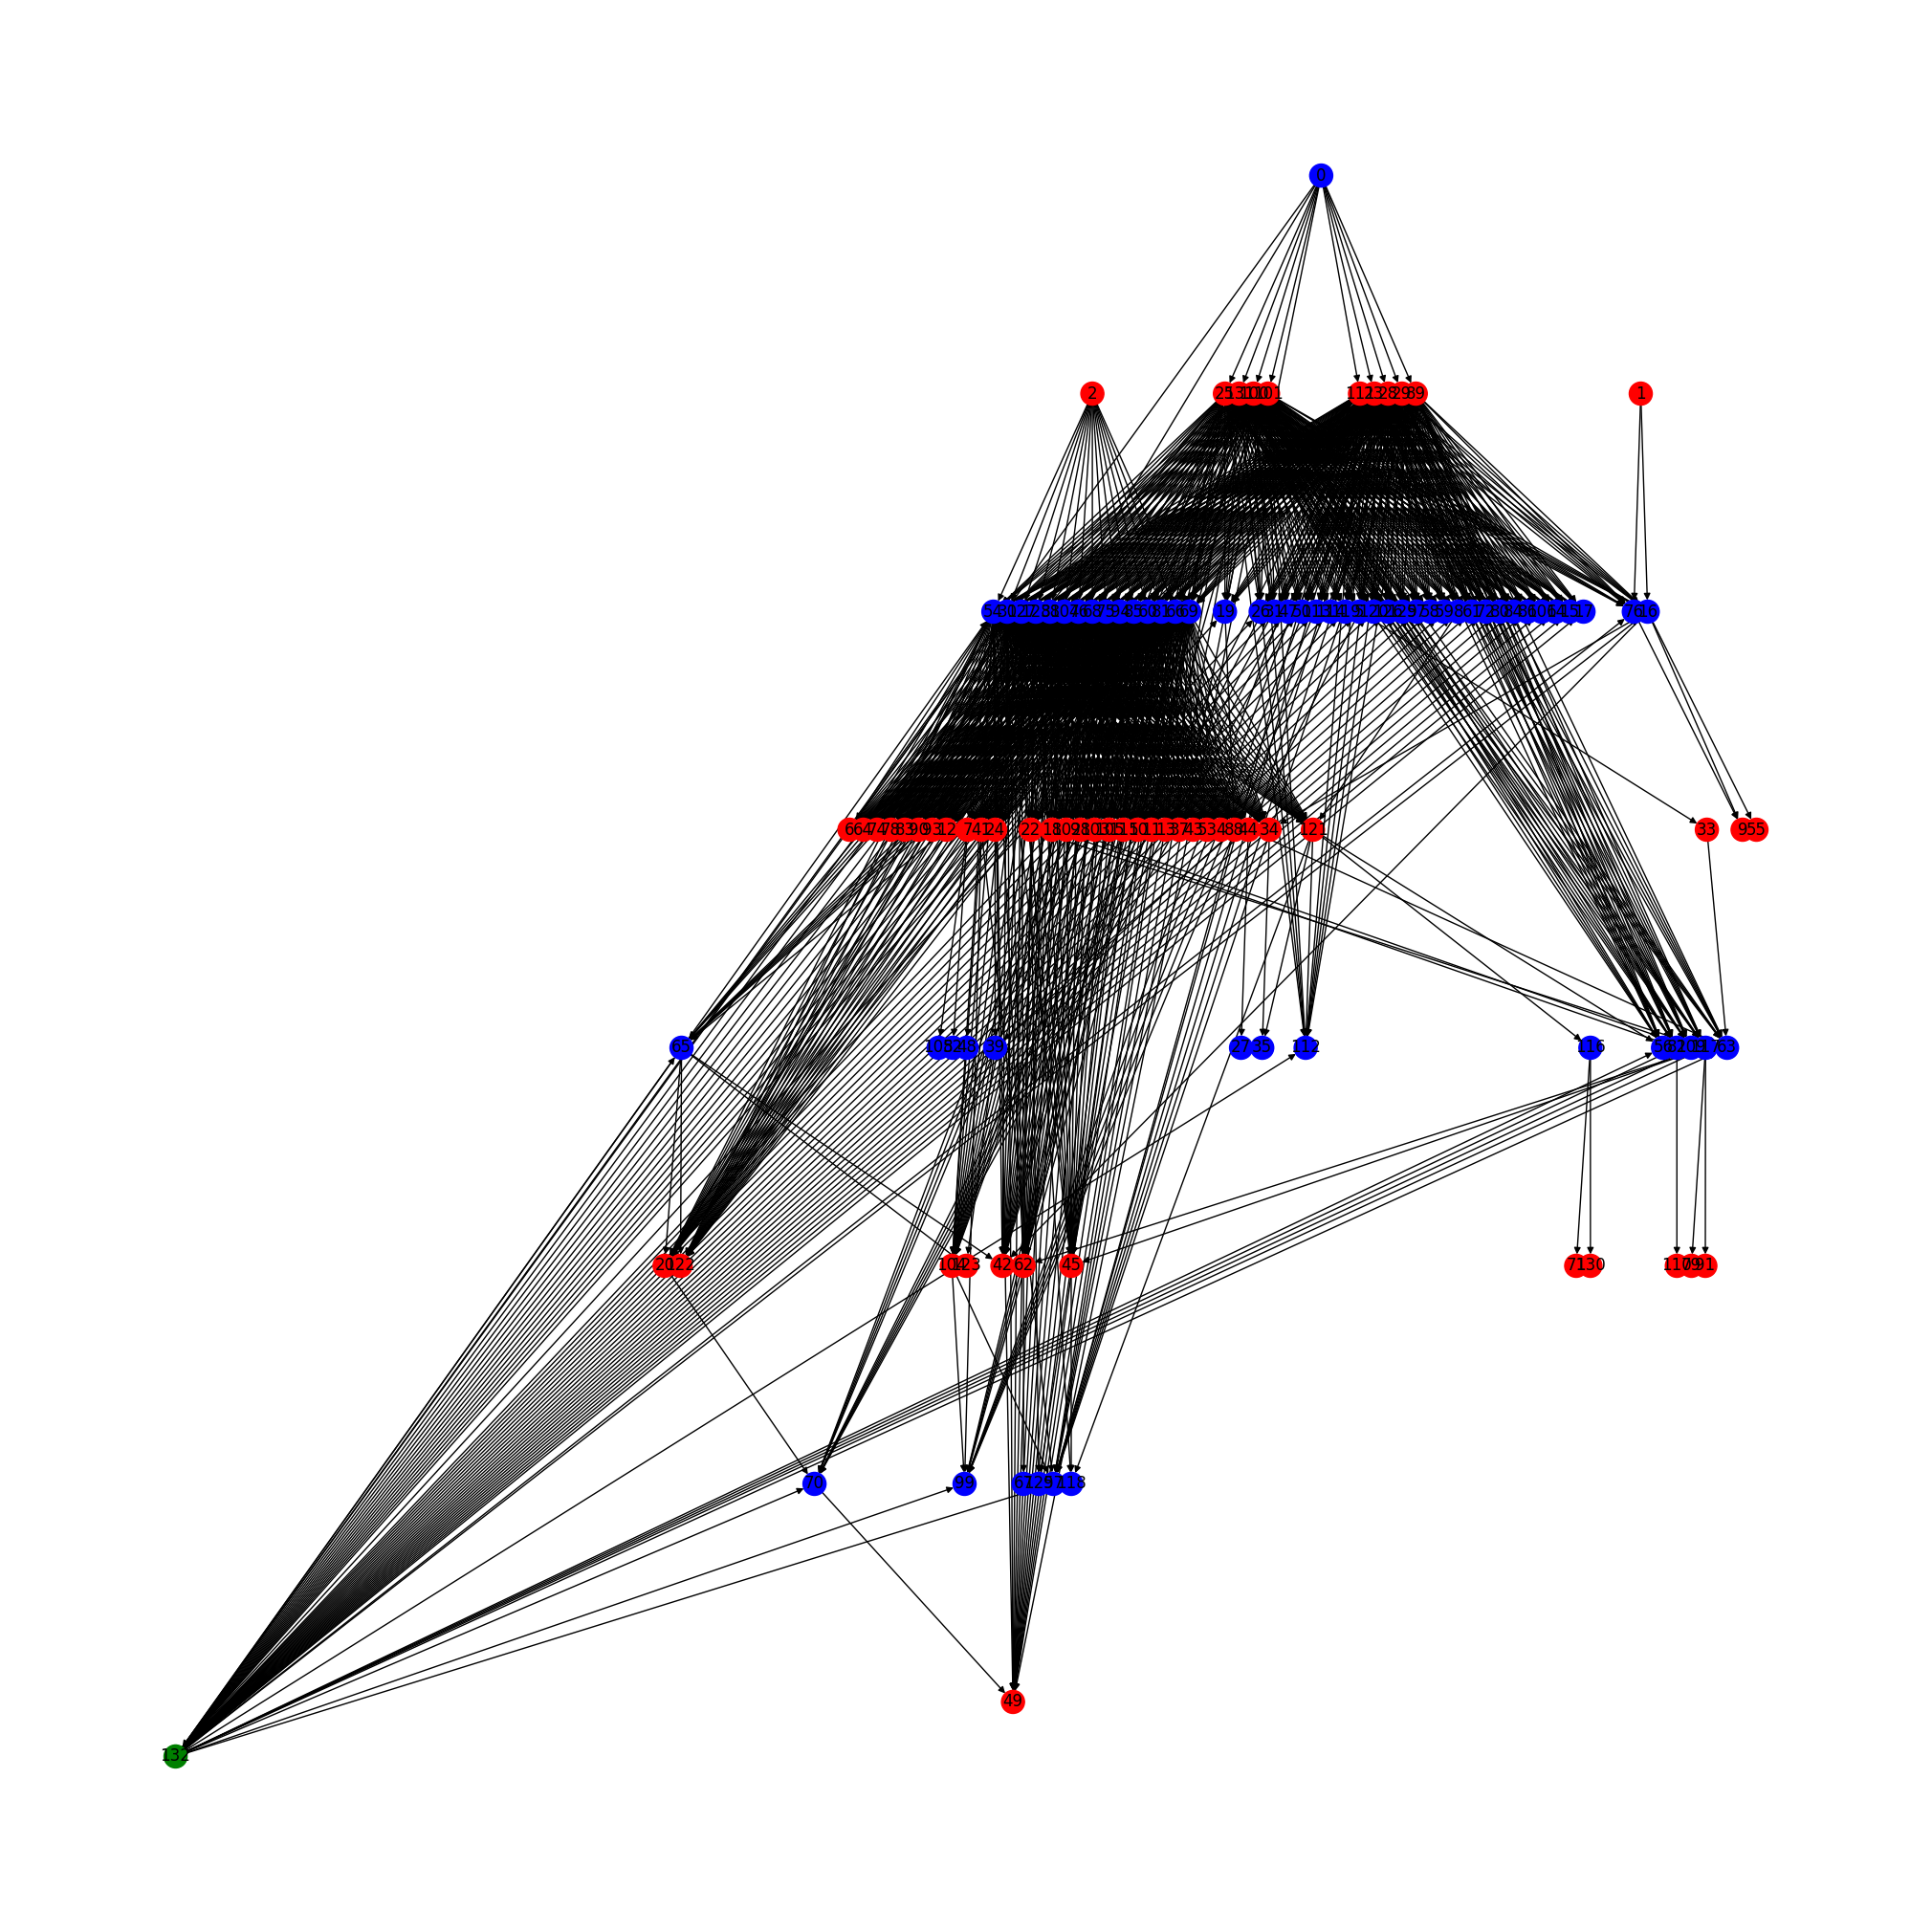

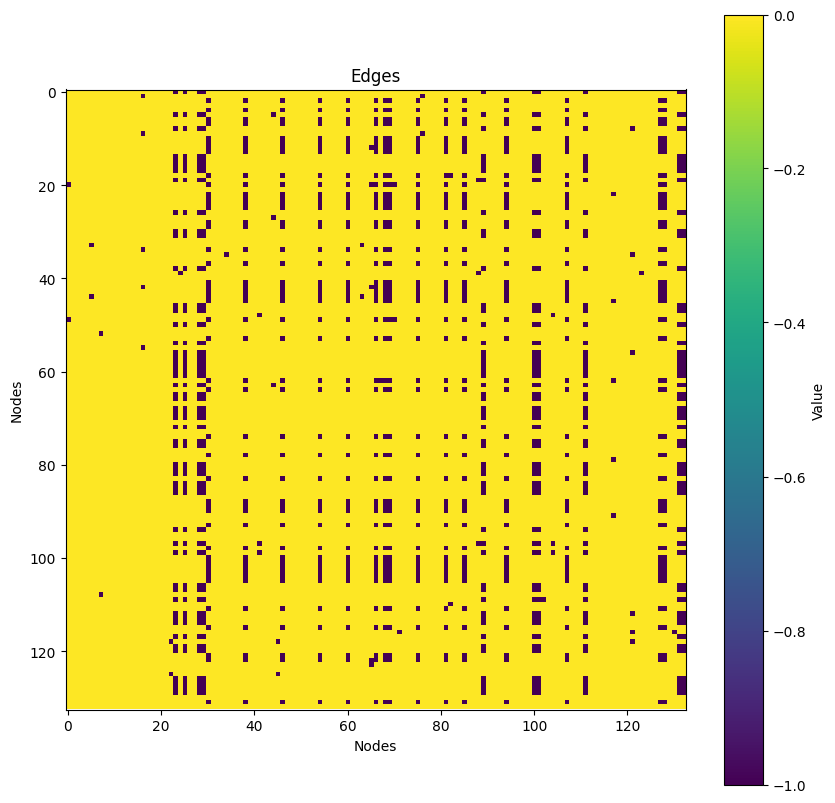

Accuracy, Precision, Recall, F1
[0.5588235294117647, 0.6363636363636364, 0.3888888888888889, 0.4827586206896552]


In [199]:
reload_imports()
results = run_model(X_train, y_train, X_val, y_val, show_graph=True)
print("Accuracy, Precision, Recall, F1")
print(results)

### Test Set

In [177]:
# reload_imports()
# print("Accuracy, Precision, Recall, F1")
# run_model(X_train_full, y_train_full, X_test, y_test, show_graph=False)